
---

# 📈 ***`Polynomial Regression in Machine Learning for Data Science`*** 🚀  

### ✅ **What is Polynomial Regression?**  
📌 **Polynomial Regression** is a type of regression that models the relationship between **independent variables (X)** and **dependent variable (Y)** using a **polynomial equation** rather than a straight line.  

It is an extension of **Linear Regression**, where the equation includes **higher-degree terms** of the input variables to capture **non-linear relationships**.

### 🔹 **Mathematical Equation for Polynomial Regression**  
$
Y = b_0 + b_1X + b_2X^2 + b_3X^3 + ... + b_nX^n
$
Where:  
- **$ Y $** → Dependent variable (Target)  
- **$ X $** → Independent variable (Feature)  
- **$ b_0, b_1, b_2, ... b_n $** → Regression coefficients  
- **$ n $** → Degree of the polynomial  

📌 **Key Idea:**  
- **Polynomial Regression fits a curved (non-linear) relationship** between X and Y.  
- **Unlike Linear Regression, which assumes a straight-line relationship,** Polynomial Regression captures trends in **complex datasets**.  

---

## 🎯 **1. When to Use Polynomial Regression?**  

✅ **Use Polynomial Regression when:**  
✔ The relationship between variables is **non-linear**.  
✔ A straight line **does not fit the data well**.  
✔ You need to model **curved trends** (e.g., stock prices, growth trends, physics simulations).  

❌ **Avoid it when:**  
- Data is truly **linear** (use simple Linear Regression instead).  
- Overfitting occurs due to **high-degree polynomials**.  
- There’s a risk of **poor generalization on unseen data**.  

---

## 🏹 **2. Implementing Polynomial Regression in Python**  

### **📁 Dataset Example: Predicting Salary Based on Experience**  

e:\Data Science Materials\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


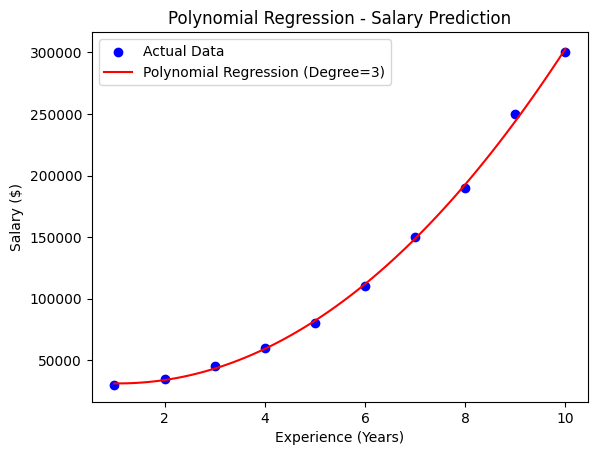

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Sample Dataset
data = {
    'Experience (Years)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary ($)': [30000, 35000, 45000, 60000, 80000, 110000, 150000, 190000, 250000, 300000]
}
df = pd.DataFrame(data)

# Features & Target
X = df[['Experience (Years)']]
y = df['Salary ($)']

# Train Polynomial Regression Model (Degree 3)
poly_reg = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)), 
    ('linear_model', LinearRegression())
])

poly_reg.fit(X, y)

# Predictions
X_pred = np.linspace(1, 10, 100).reshape(-1, 1)  # Creating smooth curve points
y_pred = poly_reg.predict(X_pred)

# Visualization
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X_pred, y_pred, color='red', label="Polynomial Regression (Degree=3)")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Polynomial Regression - Salary Prediction")
plt.legend()
plt.show()

📊 **Observations:**  
✔ **Red Curve** → Captures **non-linear trends** in salary growth.  
✔ **Blue Points** → Actual data points.  
✔ **Degree 3 Polynomial** models salary growth better than a straight line.  

---

## 📏 **3. Choosing the Right Polynomial Degree**  

📌 **Degree selection is crucial:**  
- **Low Degree (n=1, 2)** → May **underfit** the data (not capturing patterns).  
- **Optimal Degree** → Captures **trends well** while preventing overfitting.  
- **High Degree (n ≥ 6, 10)** → Overfits training data, causing **poor generalization**.

📌 **Visualizing Different Polynomial Degrees**

e:\Data Science Materials\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
e:\Data Science Materials\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
e:\Data Science Materials\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
e:\Data Science Materials\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


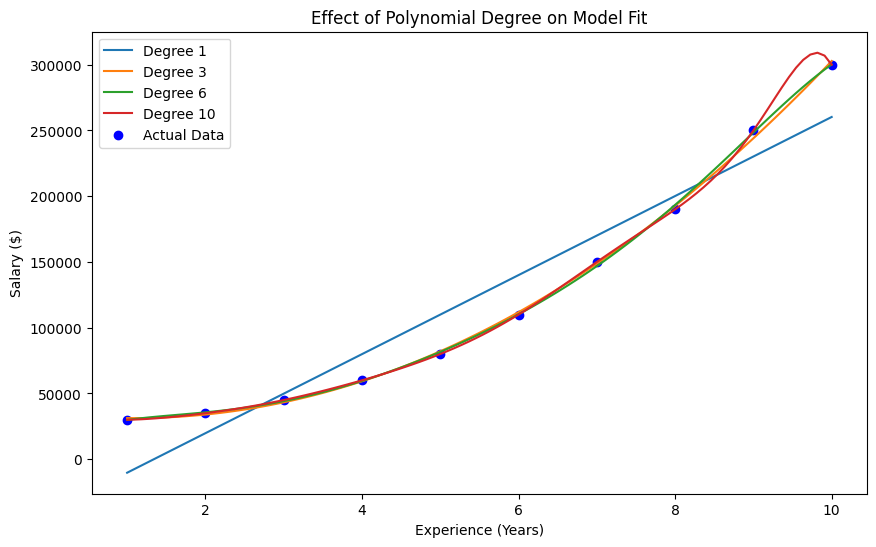

In [2]:
degrees = [1, 3, 6, 10]
plt.figure(figsize=(10, 6))

for d in degrees:
    poly_reg = Pipeline([
        ('poly_features', PolynomialFeatures(degree=d)), 
        ('linear_model', LinearRegression())
    ])
    
    poly_reg.fit(X, y)
    y_pred = poly_reg.predict(X_pred)
    
    plt.plot(X_pred, y_pred, label=f"Degree {d}")

plt.scatter(X, y, color='blue', label="Actual Data")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Effect of Polynomial Degree on Model Fit")
plt.legend()
plt.show()


📌 **Observations:**  
✔ **Degree = 1 (Linear Regression)** → Does not capture the curve.  
✔ **Degree = 3** → **Optimal**, fits well without overfitting.  
✔ **Degree = 6 & 10** → Overfitting (too wavy, not smooth).  

💡 **Pro Tip:** Use **Cross-Validation (CV)** to find the best degree **automatically**.

---

## 📉 **4. Evaluating Polynomial Regression Models**  

📌 **Common Regression Metrics:**  
| **Metric** | **Formula** | **Interpretation** |
|------------|------------|---------------------|
| **Mean Squared Error (MSE)** | $ \frac{1}{n} \sum (Y - \hat{Y})^2 $ | Lower is better |
| **Root Mean Squared Error (RMSE)** | $ \sqrt{MSE} $ | Measures error in real units |
| **R² Score** | $ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $ | Closer to **1** is better |

📌 **Model Evaluation Example:**

In [3]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions on Training Data
y_train_pred = poly_reg.predict(X)

# Compute Metrics
mse = mean_squared_error(y, y_train_pred)
r2 = r2_score(y, y_train_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 4.604190681368747e-09
R² Score: 1.0


📊 **Interpretation:**  
✔ **Low MSE & High R² Score** → Indicates a **good model fit**.  
✔ If **R² Score is close to 1**, the model explains most of the variance.  

---

## 🛠 **5. Polynomial Regression vs. Linear Regression**  

📌 **Key Differences:**
| **Aspect** | **Linear Regression** | **Polynomial Regression** |
|------------|-----------------|-------------------|
| **Equation** | $ Y = b_0 + b_1X $ | $ Y = b_0 + b_1X + b_2X^2 + b_3X^3 $ |
| **Relationship** | Straight-line | Curved (non-linear) |
| **Captures Complexity?** | ❌ No | ✅ Yes |
| **Overfitting Risk?** | ❌ Low | ✅ High (if degree is too high) |

📌 **When to Use Which?**  
- **Linear Regression** → Use when data shows a **straight-line trend**.  
- **Polynomial Regression** → Use when data follows **a curved pattern**.  

---

## 🌎 **6. Real-World Applications of Polynomial Regression**  

📌 **Where is Polynomial Regression Used?**  
✔ **Stock Market Trends** → Predict stock price fluctuations.  
✔ **Physics & Engineering** → Modeling **non-linear forces, motion, etc.**  
✔ **Healthcare** → Disease progression curves.  
✔ **Marketing & Sales** → **Advertising spend vs. revenue growth**.  

---

## 🏆 **7. Key Takeaways**  

✔ **Polynomial Regression models curved relationships** better than Linear Regression.  
✔ **Choosing the right polynomial degree** is crucial to avoid **overfitting**.  
✔ **Cross-validation helps find the best polynomial degree** automatically.  
✔ **Polynomial Regression is widely used** in Finance, Engineering, Healthcare, and more.  
✔ **Evaluated using MSE, RMSE, and R² Score** to ensure good model fit.  

💡 **Pro Tip:** If your dataset has **multiple features**, apply **PolynomialFeatures** to all of them to create interaction terms!

---